In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import sys
import os
sys.path.append(os.path.abspath(".."))
from core_ntsa.chhabra_algorithm import chhabra_jensen_spectrum
from core_ntsa.generators import simulate_lorenz
from core_ntsa.noise_tools import add_white_noise, add_colored_noise
from scipy.stats import linregress


lorenz_data = simulate_lorenz(t_span=50.0, dt=0.01)
clean_x = lorenz_data[0]

x_white_noise = add_white_noise(clean_x, snr_db=10.0)
x_clored_noise = add_colored_noise(clean_x, color='pink', snr_db=10.0)

# Chhabra Algorithm

In [4]:
def get_entropy_numerator(prob_dict, q):
    """
    Hàm phụ trợ để trích xuất tử số entropy nhằm phục vụ vẽ Đồ thị 1.
    """
    scales = np.sort(list(prob_dict.keys()))
    numerators = np.zeros(len(scales))
    for j, L in enumerate(scales):
        P = prob_dict[L]
        P = P[P > 0]
        log_P = np.log(P)
        
        log_mu_unnorm = q * log_P
        log_mu_unnorm -= np.max(log_mu_unnorm)
        mu = np.exp(log_mu_unnorm)
        mu /= np.sum(mu)
        
        numerators[j] = np.sum(mu * np.log(mu))
    return np.log(scales), numerators

if __name__ == "__main__":
    # =================================================================
    # BƯỚC 1: TẠO DỮ LIỆU CANTOR 2 TỶ LỆ
    # =================================================================
    N_max = 12
    p1, p2 = 0.7, 0.3
    
    prob_dict_1 = {}
    P_current = np.array([1.0])
    
    for n in range(1, N_max + 1):
        P_new = np.zeros(2**n)
        P_new[0::2] = P_current * p1
        P_new[1::2] = P_current * p2
        P_current = P_new
        
        L = 2.0**(-n)
        prob_dict_1[L] = P_current

    # =================================================================
    # BƯỚC 2: THIẾT LẬP KỊCH BẢN THỰC TẾ (LỆCH CƠ SỐ)
    # =================================================================
    finest_P = prob_dict_1[2.0**(-N_max)]
    x_centers = (np.arange(2**N_max) + 0.5) * (2.0**(-N_max))
    
    prob_dict_2 = {}
    # Quét kích thước L = 1.1^-n, giới hạn không nhỏ hơn độ phân giải dữ liệu
    for n in range(5, 65): 
        L = 1.1**(-n)
        if L < 2.0**(-N_max + 2):
            break
            
        # Box-counting bằng cách gom điểm khối lượng vào các ô L
        box_indices = (x_centers / L).astype(int)
        P_box = np.bincount(box_indices, weights=finest_P)
        prob_dict_2[L] = P_box[P_box > 0]

    # =================================================================
    # BƯỚC 3: TÍNH TOÁN VÀ TRỰC QUAN HÓA (PLOTTING)
    # =================================================================
    q_test = [1, 2, 3]
    q_range = np.linspace(-10, 10, 50)
    
    # Tính phổ f(alpha) cho cả 2 kịch bản
    alpha_1, f_1 = chhabra_jensen_spectrum(prob_dict_1, q_range)
    alpha_2, f_2 = chhabra_jensen_spectrum(prob_dict_2, q_range)
    
    # Tính tọa độ giải tích lý thuyết để đối chiếu
    alpha_min_theory = np.log(p1) / np.log(0.5)
    alpha_max_theory = np.log(p2) / np.log(0.5)
    
    plt.figure(figsize=(14, 6))

    # --- Đồ thị 1: Semi-log Plot ---
    plt.subplot(1, 2, 1)
    colors = ['blue', 'green', 'red']
    for idx, q in enumerate(q_test):
        log_L_1, num_1 = get_entropy_numerator(prob_dict_1, q)
        log_L_2, num_2 = get_entropy_numerator(prob_dict_2, q)
        
        plt.plot(log_L_1, num_1, 'o-', color=colors[idx], label=f'KB1 (L=2^-n): q={q}')
        plt.plot(log_L_2, num_2, 's', color=colors[idx], alpha=0.5, label=f'KB2 (L=1.1^-n): q={q}')
        
        # Hồi quy tuyến tính cho kịch bản 2 để thấy rõ xu hướng dao động
        slope, intercept, _, _, _ = linregress(log_L_2, num_2)
        plt.plot(log_L_2, slope * log_L_2 + intercept, '--', color=colors[idx])

    plt.title("Đồ thị 1: Tuyến tính Entropy vs log(L)")
    plt.xlabel("log(L)")
    plt.ylabel("Tử số f(q): sum(mu * log(mu))")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize='small')

    # --- Đồ thị 2: Singularity Spectrum f(alpha) ---
    plt.subplot(1, 2, 2)
    plt.plot(alpha_1, f_1, 'o-', color='blue', label='Kịch bản 1 (Lý tưởng)')
    plt.plot(alpha_2, f_2, 's--', color='red', alpha=0.7, label='Kịch bản 2 (Lệch cơ số)')
    
    # Đánh dấu các mốc lý thuyết
    plt.axvline(alpha_min_theory, color='gray', linestyle=':', label='alpha_min (Lý thuyết)')
    plt.axvline(alpha_max_theory, color='black', linestyle=':', label='alpha_max (Lý thuyết)')
    plt.axhline(1.0, color='green', linestyle=':', label='D_0 = 1.0 (Lý thuyết)')
    
    plt.title("Đồ thị 2: Phổ kỳ dị f(alpha)")
    plt.xlabel("Sức mạnh kỳ dị (alpha)")
    plt.ylabel("Số chiều fractal f(alpha)")
    plt.ylim(0, 1.1)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # In thông số kiểm định
    print("=== BÁO CÁO KIỂM THỬ GIẢI TÍCH ===")
    print(f"Alpha_min (Lý thuyết): {alpha_min_theory:.4f} | Thực nghiệm (KB1): {np.min(alpha_1):.4f}")
    print(f"Alpha_max (Lý thuyết): {alpha_max_theory:.4f} | Thực nghiệm (KB1): {np.max(alpha_1):.4f}")
    print(f"D_0 cực đại (q=0): {np.max(f_1):.4f} (Tiêu chuẩn: 1.0000)")

NameError: name 'chhabra_jensen_spectrum' is not defined

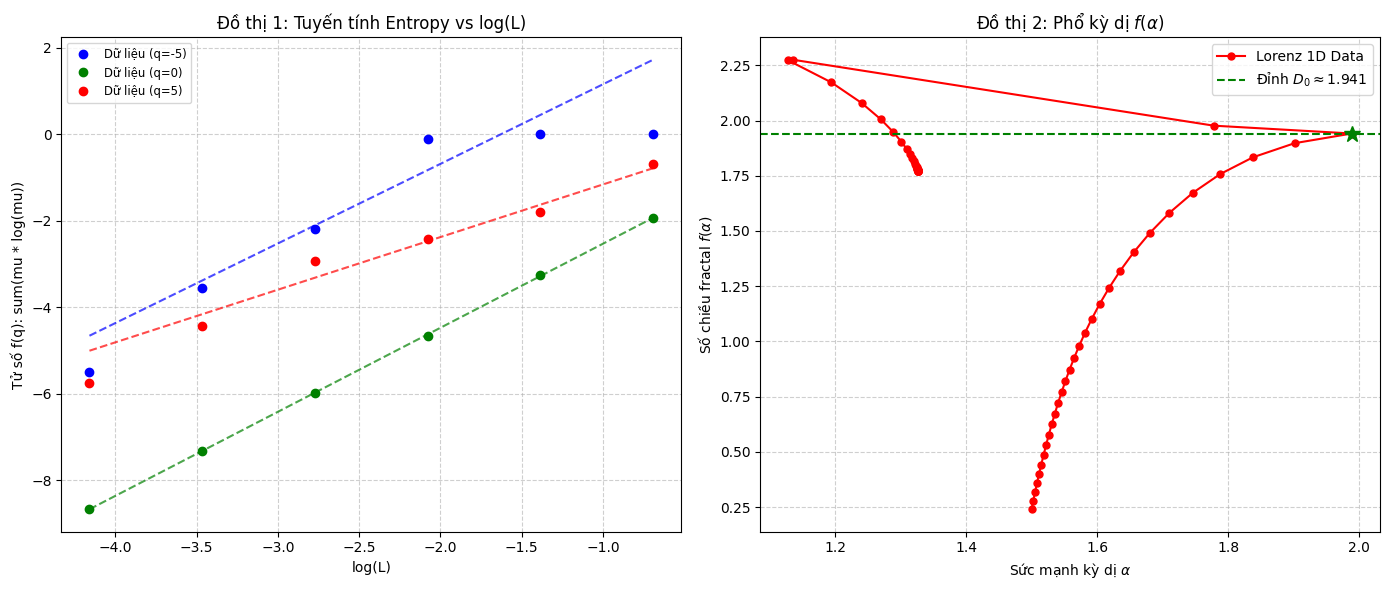

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# =====================================================================
# MODULE PHỤ TRỢ: TRÍCH XUẤT TỬ SỐ ENTROPY
# =====================================================================
def get_entropy_numerator(prob_dict, q):
    """Tính tử số entropy sum(mu * log(mu)) phục vụ vẽ Đồ thị 1."""
    scales = np.sort(list(prob_dict.keys()))
    numerators = np.zeros(len(scales))
    
    for j, L in enumerate(scales):
        P = prob_dict[L]
        P = P[P > 0]
        log_P = np.log(P)
        
        log_mu_unnorm = q * log_P
        log_mu_unnorm -= np.max(log_mu_unnorm)
        mu = np.exp(log_mu_unnorm)
        mu /= np.sum(mu)
        
        numerators[j] = np.sum(mu * np.log(mu))
        
    return np.log(scales), numerators

# =====================================================================
# 3. MODULE TIỀN XỬ LÝ: TAKENS & BOX-COUNTING
# =====================================================================
def delay_embedding(series, tau, m):
    """Nhúng chuỗi 1D vào không gian m chiều."""
    N = len(series)
    Nm = N - (m - 1) * tau
    if Nm <= 0:
        raise ValueError("Dữ liệu quá ngắn để nhúng.")
    X = np.array([series[i : i + (m - 1) * tau + 1 : tau] for i in range(Nm)])
    return X

def box_counting_measure(X, scales):
    """Bủa lưới không gian pha và đếm xác suất P_i."""
    prob_dict = {}
    X_min = np.min(X, axis=0)
    X_max = np.max(X, axis=0)
    X_norm = (X - X_min) / (X_max - X_min + 1e-12)
    
    for L in scales:
        box_indices = np.floor(X_norm / L).astype(int)
        _, counts = np.unique(box_indices, axis=0, return_counts=True)
        prob_dict[L] = counts / np.sum(counts)
        
    return prob_dict

# =====================================================================
# 4. THỰC THI PIPELINE VÀ VẼ ĐỒ THỊ
# =====================================================================
if __name__ == "__main__":
    # Giả định biến clean_x đã tồn tại trong không gian làm việc

    # 4.1 Nhúng Takens
    tau_val = 16
    m_val = 3
    X_embedded = delay_embedding(clean_x, tau=tau_val, m=m_val)

    # 4.2 Box-counting
    scale_range = 2.0 ** (-np.arange(1, 7))
    probabilities_lorenz = box_counting_measure(X_embedded, scale_range)

    # 4.3 Tính phổ Chhabra-Jensen
    q_vals = np.linspace(-15, 15, 60)
    valid_region = slice(1, -1) 
    alpha_lorenz, f_lorenz = chhabra_jensen_spectrum(
        probabilities_lorenz, 
        q_vals, 
        scale_slice=valid_region
    )

    # 4.4 Trực quan hóa
    fig = plt.figure(figsize=(14, 6))

    # --- Đồ thị 1: Tuyến tính Entropy vs log(L) ---
    plt.subplot(1, 2, 1)
    q_test = [-5, 0, 5]
    colors = ['blue', 'green', 'red']
    
    for idx, q in enumerate(q_test):
        log_L, num = get_entropy_numerator(probabilities_lorenz, q)
        
        # Chỉ dùng các điểm trong valid_region để kẻ đường hồi quy tuyến tính
        log_L_valid = log_L[valid_region]
        num_valid = num[valid_region]
        
        plt.plot(log_L, num, 'o', color=colors[idx], label=f'Dữ liệu (q={q})')
        
        slope, intercept, _, _, _ = linregress(log_L_valid, num_valid)
        plt.plot(log_L, slope * log_L + intercept, '--', color=colors[idx], alpha=0.7)

    plt.title("Đồ thị 1: Tuyến tính Entropy vs log(L)")
    plt.xlabel("log(L)")
    plt.ylabel("Tử số f(q): sum(mu * log(mu))")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize='small')

    # --- Đồ thị 2: Singularity Spectrum f(alpha) ---
    plt.subplot(1, 2, 2)
    plt.plot(alpha_lorenz, f_lorenz, 'o-', color='red', markersize=5, label=r'Lorenz 1D Data')
    
    idx_q0 = np.argmin(np.abs(q_vals))
    D_0 = f_lorenz[idx_q0]
    
    plt.axhline(D_0, color='green', linestyle='--', label=rf"Đỉnh $D_0 \approx {D_0:.3f}$")
    plt.plot(alpha_lorenz[idx_q0], D_0, 'g*', markersize=12)
    
    plt.title(r"Đồ thị 2: Phổ kỳ dị $f(\alpha)$")
    plt.xlabel(r"Sức mạnh kỳ dị $\alpha$")
    plt.ylabel(r"Số chiều fractal $f(\alpha)$")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

Đang tạo tập dữ liệu N_small (10^4 điểm)...
Đang tạo tập dữ liệu N_large (10^6 điểm) - Vui lòng đợi...
Hoàn tất tạo N_large trong 4.34 giây.
Đang chạy phân tích Box-counting...


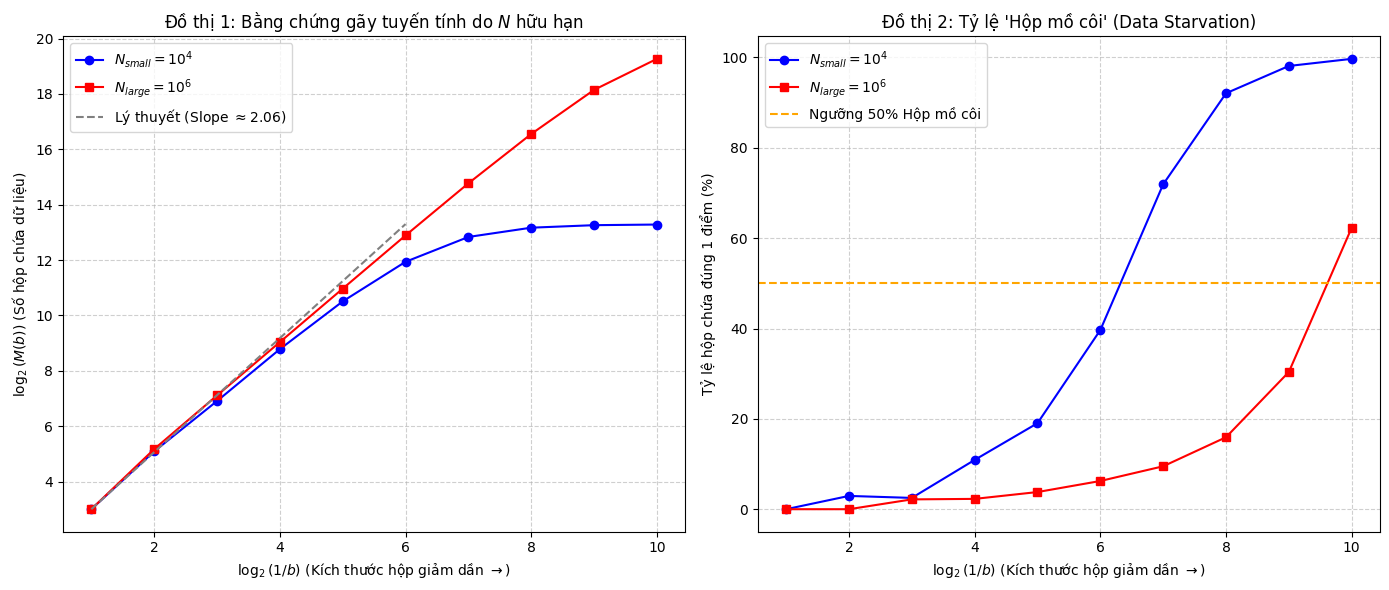

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import time

# =====================================================================
# 1. TẠO DỮ LIỆU ĐỐI CHỨNG (LORENZ 3D GỐC)
# =====================================================================
def simulate_lorenz_3d(N, dt=0.01):
    """Giả lập hệ Lorenz 3D chuẩn, cắt bỏ 1000 bước đầu (nhiễu quá độ)."""
    def lorenz_deriv(xyz, t, sigma=10.0, beta=8.0/3.0, rho=28.0):
        x, y, z = xyz
        return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]
    
    t = np.arange(0, (N + 1000) * dt, dt)
    state0 = [1.0, 1.0, 1.0]
    states = odeint(lorenz_deriv, state0, t)
    
    # Loại bỏ nhiễu quá độ (transient) và trả về N điểm
    return states[1000:, :]

# =====================================================================
# 2. BOX-COUNTING: TRÍCH XUẤT CÁC THAM SỐ CHỨNG MINH
# =====================================================================
def analyze_data_starvation(X, scales):
    """
    Thực thi Box-counting và đo lường 3 tham số:
    - M_b: Tổng số hộp có dữ liệu.
    - S_b: Entropy Shannon.
    - orphan_ratio: Tỷ lệ % hộp mồ côi (chứa đúng 1 điểm).
    """
    M_b = np.zeros(len(scales))
    S_b = np.zeros(len(scales))
    orphan_ratio = np.zeros(len(scales))
    
    # Chuẩn hóa về [0, 1]^3
    X_min = np.min(X, axis=0)
    X_max = np.max(X, axis=0)
    X_norm = (X - X_min) / (X_max - X_min + 1e-12)
    
    N_total = X.shape[0]
    
    for i, b in enumerate(scales):
        box_indices = np.floor(X_norm / b).astype(int)
        _, counts = np.unique(box_indices, axis=0, return_counts=True)
        
        # 1. Tổng số hộp có dữ liệu
        M_b[i] = len(counts)
        
        # 2. Entropy Shannon
        p_i = counts / N_total
        S_b[i] = -np.sum(p_i * np.log(p_i))
        
        # 3. Tỷ lệ "Hộp mồ côi"
        orphan_count = np.sum(counts == 1)
        orphan_ratio[i] = (orphan_count / len(counts)) * 100.0
        
    return M_b, S_b, orphan_ratio

# =====================================================================
# 3. THỰC THI PIPELINE VÀ VẼ ĐỒ THỊ BÁO CÁO
# =====================================================================
if __name__ == "__main__":
    print("Đang tạo tập dữ liệu N_small (10^4 điểm)...")
    X_small = simulate_lorenz_3d(10**4)
    
    print("Đang tạo tập dữ liệu N_large (10^6 điểm) - Vui lòng đợi...")
    start_time = time.time()
    X_large = simulate_lorenz_3d(10**6)
    print(f"Hoàn tất tạo N_large trong {time.time() - start_time:.2f} giây.")
    
    # Thiết lập kích thước hộp b giảm dần (từ 2^-1 đến 2^-10)
    b_scales = 2.0 ** (-np.arange(1, 11))
    log_1_over_b = np.log2(1.0 / b_scales)
    
    print("Đang chạy phân tích Box-counting...")
    M_small, S_small, orphan_small = analyze_data_starvation(X_small, b_scales)
    M_large, S_large, orphan_large = analyze_data_starvation(X_large, b_scales)
    
    # --- Vẽ Đồ thị ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Đồ thị 1: Log-Log của D0 (log(M_b) vs log(1/b))
    ax1.plot(log_1_over_b, np.log2(M_small), 'o-', color='blue', label=r'$N_{small} = 10^4$')
    ax1.plot(log_1_over_b, np.log2(M_large), 's-', color='red', label=r'$N_{large} = 10^6$')
    
    # Vẽ đường xu hướng lý thuyết D0 = 2.06
    # Dịch chuyển đường lý thuyết để dễ so sánh bằng mắt
    x_theory = log_1_over_b[:6]
    y_theory_small = 2.06 * x_theory + (np.log2(M_small[0]) - 2.06 * x_theory[0])
    ax1.plot(x_theory, y_theory_small, '--', color='gray', label=r'Lý thuyết (Slope $\approx 2.06$)')
    
    ax1.set_title(r"Đồ thị 1: Bằng chứng gãy tuyến tính do $N$ hữu hạn")
    ax1.set_xlabel(r"$\log_2(1/b)$ (Kích thước hộp giảm dần $\rightarrow$)")
    ax1.set_ylabel(r"$\log_2(M(b))$ (Số hộp chứa dữ liệu)")
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()
    
    # Đồ thị 2: Sự bùng nổ của "Hộp mồ côi"
    ax2.plot(log_1_over_b, orphan_small, 'o-', color='blue', label=r'$N_{small} = 10^4$')
    ax2.plot(log_1_over_b, orphan_large, 's-', color='red', label=r'$N_{large} = 10^6$')
    
    # Ngưỡng cảnh báo sụp đổ thuật toán
    ax2.axhline(50.0, color='orange', linestyle='--', label='Ngưỡng 50% Hộp mồ côi')
    
    ax2.set_title("Đồ thị 2: Tỷ lệ 'Hộp mồ côi' (Data Starvation)")
    ax2.set_xlabel(r"$\log_2(1/b)$ (Kích thước hộp giảm dần $\rightarrow$)")
    ax2.set_ylabel(r"Tỷ lệ hộp chứa đúng 1 điểm (%)")
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

### 1. Đồ thị 1: Sự sụp đổ của Chiều Fractal (Hiệu ứng gãy ngang)
* **Hiện tượng:** Tại các thang đo $b$ nhỏ, đồ thị tuyến tính bị gãy ngang (hệ số góc $D_0 \to 0$). Thuật toán hoàn toàn bị "mù".
* **Bản chất toán học:** Số lượng hộp chứa dữ liệu bị khóa ở trần tối đa là tổng số điểm quan sát: $M(b)_{max} = N$. (Ví dụ: Tập $N=10^4$ gãy ngang tại trần $\log_2(10000) \approx 13.28$).
* **Kết luận:** Giới hạn $b \to 0$ là bất khả thi với dữ liệu ngắn. Để khảo sát vi mô mà không gãy tuyến tính, bắt buộc $N \to \infty$.

### 2. Đồ thị 2: Nguyên nhân vỡ phổ kỳ dị nhánh phải ($q < 0$)
* **Sự bùng nổ "Hộp mồ côi":** Khi $b$ vượt ngưỡng, các hộp chỉ chứa đúng 1 điểm dữ liệu tăng phi mã lên gần $100\%$.
* **Tác động lên Chhabra-Jensen:** Xác suất của hộp mồ côi rất nhỏ ($P_i = 1/N$). Lăng kính $q < 0$ (ví dụ $q = -10$) sẽ khuếch đại $P_i^{-10}$ thành những con số khổng lồ vô lý, đánh sập thuật toán.
* **Kết luận:** Sự xô lệch ở nhánh phải của phổ $f(\alpha)$ thực chất là thước đo "Nhiễu do thiếu hụt dữ liệu" (Data Starvation), hoàn toàn không phản ánh đặc tính phân dạng tự nhiên của hệ thống.

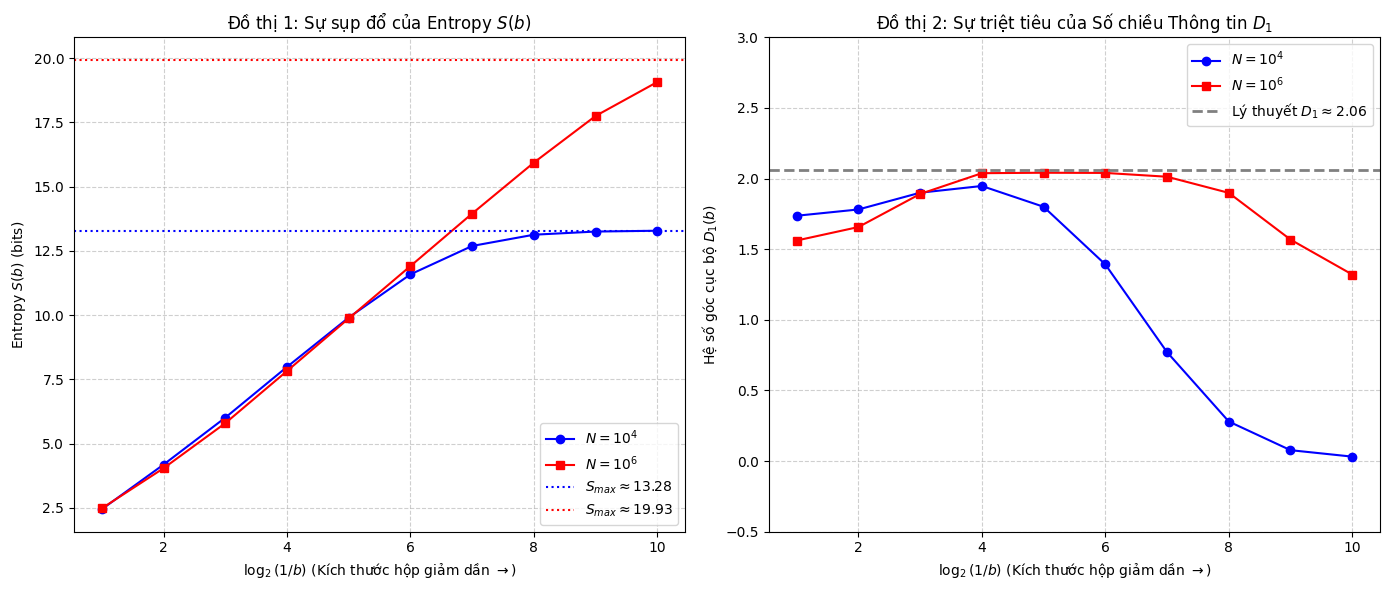

In [ ]:
# ta chuyển sang cơ số 2 để đồng nhất với trục hoành log2(1/b).
S_small_log2 = S_small / np.log(2)
S_large_log2 = S_large / np.log(2)

# Tính hệ số góc cục bộ (Local Slope D1) bằng đạo hàm rời rạc (Gradient)
D1_local_small = np.gradient(S_small_log2, log_1_over_b)
D1_local_large = np.gradient(S_large_log2, log_1_over_b)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Đồ thị 1: Biểu đồ Log-Log của S(b) ---
ax1.plot(log_1_over_b, S_small_log2, 'o-', color='blue', label=r'$N = 10^4$')
ax1.plot(log_1_over_b, S_large_log2, 's-', color='red', label=r'$N = 10^6$')

# Đánh dấu "Bức trần" cứng của Entropy
ax1.axhline(np.log2(10**4), color='blue', linestyle=':', label=r'$S_{max} \approx 13.28$')
ax1.axhline(np.log2(10**6), color='red', linestyle=':', label=r'$S_{max} \approx 19.93$')

ax1.set_title(r"Đồ thị 1: Sự sụp đổ của Entropy $S(b)$")
ax1.set_xlabel(r"$\log_2(1/b)$ (Kích thước hộp giảm dần $\rightarrow$)")
ax1.set_ylabel(r"Entropy $S(b)$ (bits)")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# --- Đồ thị 2: Hệ số góc cục bộ D1(b) ---
ax2.plot(log_1_over_b, D1_local_small, 'o-', color='blue', label=r'$N = 10^4$')
ax2.plot(log_1_over_b, D1_local_large, 's-', color='red', label=r'$N = 10^6$')

# Ngưỡng lý thuyết D1 của Lorenz (~2.06)
ax2.axhline(2.06, color='gray', linestyle='--', linewidth=2, label=r'Lý thuyết $D_1 \approx 2.06$')

ax2.set_title(r"Đồ thị 2: Sự triệt tiêu của Số chiều Thông tin $D_1$")
ax2.set_xlabel(r"$\log_2(1/b)$ (Kích thước hộp giảm dần $\rightarrow$)")
ax2.set_ylabel(r"Hệ số góc cục bộ $D_1(b)$")
ax2.set_ylim(-0.5, 3.0)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

### 1. Tác động của Kích thước hộp ($b$)
* **Vùng hợp lệ ($b$ lớn):** Dữ liệu phân bố đủ dày đặc. Box-counting hoạt động chính xác, Entropy tăng tuyến tính theo $\log_2(1/b)$.
* **Vùng cạn kiệt ($b$ quá nhỏ):** Kích thước hộp nhỏ hơn độ phân giải dữ liệu, sinh ra các "hộp mồ côi" ($\le 1$ điểm). Thuật toán mất hiệu lực, chuyển sang đo lường khoảng trống (nhiễu).

### 2. Tác động của Số lượng dữ liệu ($N$)
* **Bức trần Entropy:** $N$ thiết lập giới hạn thông tin tuyệt đối. Entropy bị khóa cứng tại $S_{max} = \log_2(N)$ (đạt $\approx 13.28$ với $N=10^4$, và $\approx 19.93$ với $N=10^6$).
* **Trì hoãn sự sụp đổ:** Việc tăng $N$ không ngăn được hiện tượng sụp đổ thuật toán mà chỉ mở rộng Vùng chia tỷ lệ (Scaling Region), cho phép khảo sát ở các thang đo vi mô sâu hơn trước khi xảy ra Data Starvation.

### 3. Hệ lụy lên Số chiều Thông tin ($D_1$)
* **Sự triệt tiêu $D_1$:** Vì $D_1$ là đạo hàm của đường cong Entropy, khi Entropy chạm trần $S_{max}$ và đi ngang, $D_1$ lập tức lao thẳng đứng về $0$.
* **Ảo ảnh tính toán (Undershoot):** Phép hồi quy tại vùng cạn kiệt sẽ sinh ra số chiều giả tạo cực thấp (ví dụ $D_1 \approx 0.25$ tại $\log_2(1/b) = 8$). Đây là sai số thuần túy do thiếu hụt mẫu, hoàn toàn không phản ánh bản chất động lực học của hệ thống.

### Hạn chế chí mạng của Box-counting đối với Số chiều Tổng quát ($D_q$)

1. **Lời nguyền số chiều (Data Starvation):** Dữ liệu hữu hạn ($N$) không thể lấp đầy số lượng hộp tăng theo cấp số mũ ở các thang đo nhỏ. Sự pha loãng này ép Entropy chạm trần, làm triệt tiêu hệ số góc và khiến mọi phép đo $D_q \to 0$.

2. **Vỡ phổ kỳ dị khi $q < 0$ (Khuếch đại nhiễu):** Lăng kính $q < 0$ phóng đại nghịch đảo xác suất của các "hộp mồ côi" (chỉ chứa 1 điểm). Lúc này, thuật toán không đo lường cấu trúc phân dạng mà đo lường **nhiễu do thiếu hụt mẫu**, bẻ gãy hoàn toàn nhánh phải của phổ $f(\alpha)$.

3. **Hiệu ứng ranh giới cứng (Discretization Noise):** Việc áp đặt một tấm lưới tĩnh (fixed grid) lên không gian sẽ chia cắt vô lý các điểm dữ liệu nằm sát nhau trên ranh giới hộp. Hiện tượng này tạo ra các dao động gập ghềnh cục bộ, phá hỏng độ tuyến tính của đồ thị Log-Log.

4. **Sự sụp đổ của $\lim_{b \to 0}$:** Trên dữ liệu thực, bạn bị kẹt giữa hiệu ứng vĩ mô ($b$ quá lớn) và vùng cạn kiệt ($b$ quá nhỏ). Việc tìm kiếm "Vùng chia tỷ lệ" (Scaling Region) để tính hồi quy bị phụ thuộc vào đánh giá chủ quan của người quan sát, làm mất đi tính nghiêm ngặt khách quan của phép đo.